
# Surrogate-Based Optimization of a Heat Exchanger

This notebook illustrates **surrogate-based optimization** using a simple counter-current heat exchanger.

The two design variables are:

$$ L = \text{tube length (m)} $$
$$ D = \text{tube diameter (m)} $$

For every proposed pair $(L,D)$, the simulator:

1. calculates the tube-side Reynolds number and heat-transfer coefficient,
2. calculates the overall heat-transfer coefficient,
3. solves two coupled temperature ODEs along the exchanger,
4. estimates recovered heat and pumping power,
5. converts these quantities into an annual objective function.

The simulator is sampled exactly **50 times**. These 50 points are then used to train a neural-network surrogate using `sklearn.neural_network.MLPRegressor`.

Finally, the trained neural network is optimized using **BFGS from `scipy.optimize.minimize`**.

The final figure compares:

- the gridded **true simulator objective surface**, and
- the **MLP surrogate surface**.

Both plots mark the true grid optimum and the surrogate optimum found by `scipy` BFGS.


## 1. Heat-exchanger model

For a differential exchanger length $dx$,

$$
dQ = UP(T_h-T_c)\,dx
$$

where $U$ is the overall heat-transfer coefficient and $P$ is the total heat-transfer perimeter.

Taking $x$ in the hot-stream flow direction, the two counter-current temperature equations are

$$
\frac{dT_h}{dx}
=
-\frac{UP}{\dot m_h c_{p,h}}
(T_h-T_c)
$$

and

$$
\frac{dT_c}{dx}
=
-\frac{UP}{\dot m_c c_{p,c}}
(T_h-T_c).
$$

The boundary conditions occur at opposite ends:

$$
T_h(0)=T_{h,\mathrm{in}}
$$

$$
T_c(L)=T_{c,\mathrm{in}}.
$$

Therefore, the temperature model is solved as a two-point boundary-value problem using `scipy.integrate.solve_bvp`.

The annual objective is

$$
J(L,D)
=
C_{\mathrm{capital}}
+
C_{\mathrm{pump}}
+
C_{\mathrm{maintenance}}
+
C_{\mathrm{installation}}
-
S_{\mathrm{heat}},
$$

where $S_{\mathrm{heat}}$ is the annual economic value of recovered heat.

The maintenance and installation terms are simple engineering proxies that prevent the optimum from collapsing to extremely small diameters or very long exchangers. They also create a clear interior optimum for teaching surrogate optimization.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_bvp
from scipy.optimize import minimize

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# Design-variable bounds
L_MIN, L_MAX = 2.0, 12.0       # m
D_MIN, D_MAX = 0.012, 0.040   # m


## 2. Simulator parameters

The numerical values below are chosen to create a smooth but nonlinear design surface with an interior optimum. The purpose is to illustrate surrogate optimization rather than to represent a specific commercial exchanger.


In [2]:
# Fixed physical parameters
N_TUBES = 4

M_DOT_H = 0.8      # kg/s
M_DOT_C = 1.0      # kg/s

CP_H = 2300.0      # J/(kg K)
CP_C = 4180.0      # J/(kg K)

RHO_H = 850.0      # kg/m^3
MU_H = 0.003       # Pa s
K_H = 0.13         # W/(m K)

H_OUT = 700.0      # W/(m^2 K)
K_WALL = 16.0      # W/(m K)
T_WALL = 0.0015    # m

T_H_IN = 180.0     # deg C
T_C_IN = 25.0      # deg C

PUMP_EFF = 0.70

# Economic parameters
OPERATING_HOURS = 8000.0       # h/year
HEAT_VALUE = 0.030             # $/kWh thermal recovered
ELECTRICITY_PRICE = 0.12       # $/kWh
CRF = 0.12

# Simplified exchanger cost model
CAPEX_FIXED = 3000.0
CAPEX_AREA_COEFF = 5000.0
CAPEX_AREA_EXP = 1.15

# Additional annual engineering penalties used to retain a clear interior optimum
MAINTENANCE_COEFF = 0.05
INSTALLATION_COEFF = 100.0


## 3. Objective-function simulator

The tube-side Reynolds number is

$$
Re=\frac{\rho vD}{\mu}.
$$

The heat-transfer coefficient is estimated from

$$
h_i=\frac{Nu\,k}{D}.
$$

A smooth transition is used between laminar and turbulent Nusselt-number correlations so that the objective surface remains smooth and easy for the neural network to approximate.

The pressure drop is estimated with the Darcy-Weisbach equation,

$$
\Delta P
=
f\frac{L}{D}\frac{\rho v^2}{2},
$$

and pumping power is

$$
P_{\mathrm{pump}}
=
\frac{\Delta P\,\dot V}{\eta_{\mathrm{pump}}}.
$$


In [3]:
def heat_exchanger_objective(L, D, return_details=False):
    """
    Evaluate one heat-exchanger design.

    Parameters
    ----------
    L : float
        Tube length [m].
    D : float
        Tube inner diameter [m].
    return_details : bool
        If True, also return intermediate simulator outputs.

    Returns
    -------
    J : float
        Annual objective [$ / year].
    details : dict, optional
        Intermediate quantities.
    """

    # ----- Tube-side hydraulics -----
    total_flow_area = N_TUBES * np.pi * D**2 / 4.0
    velocity = M_DOT_H / (RHO_H * total_flow_area)
    Re = RHO_H * velocity * D / MU_H
    Pr = CP_H * MU_H / K_H

    # Smooth transition between laminar and turbulent correlations
    Nu_lam = 3.66
    Nu_turb = 0.023 * max(Re, 1.0)**0.8 * Pr**0.4
    transition = 1.0 / (1.0 + np.exp(-(Re - 3000.0) / 400.0))
    Nu = (1.0 - transition) * Nu_lam + transition * Nu_turb

    h_in = Nu * K_H / D

    # Overall heat-transfer coefficient
    U = 1.0 / (1.0 / h_in + T_WALL / K_WALL + 1.0 / H_OUT)

    # Total heat-transfer perimeter per unit exchanger length
    perimeter = N_TUBES * np.pi * D

    Kh = U * perimeter / (M_DOT_H * CP_H)
    Kc = U * perimeter / (M_DOT_C * CP_C)

    # ----- Coupled counter-current temperature ODEs -----
    def ode(x, y):
        delta_T = y[0] - y[1]

        dTh_dx = -Kh * delta_T
        dTc_dx = -Kc * delta_T

        return np.vstack((dTh_dx, dTc_dx))

    def boundary_conditions(ya, yb):
        return np.array([ya[0] - T_H_IN, yb[1] - T_C_IN])

    x = np.linspace(0.0, L, 30)

    # Initial guess for BVP solver
    y_guess = np.vstack((
        np.linspace(T_H_IN, 120.0, x.size),
        np.linspace(70.0, T_C_IN, x.size)
    ))

    sol = solve_bvp(ode, boundary_conditions, x, y_guess,
        tol=1e-4, max_nodes=300)

    if not sol.success:
        raise RuntimeError(f"BVP solver failed for L={L}, D={D}")

    T_h_out = sol.y[0, -1]
    T_c_out = sol.y[1, 0]

    # Recovered thermal power [W]
    Q_recovered = M_DOT_H * CP_H * (T_H_IN - T_h_out)

    # ----- Pressure drop and pumping power -----
    if Re < 2300.0:
        friction_factor = 64.0 / Re
    else:
        friction_factor = 0.3164 / Re**0.25

    delta_P = (friction_factor * (L / D) * (RHO_H * velocity**2 / 2.0))

    volumetric_flow = M_DOT_H / RHO_H
    pump_power = delta_P * volumetric_flow / PUMP_EFF

    # ----- Economic objective -----
    area = N_TUBES * np.pi * D * L

    capital_cost = (CAPEX_FIXED + CAPEX_AREA_COEFF * area**CAPEX_AREA_EXP)
    annualized_capital = CRF * capital_cost

    recovered_heat_value = (Q_recovered / 1000.0 * OPERATING_HOURS * HEAT_VALUE)
    annual_pump_cost = (pump_power / 1000.0 * OPERATING_HOURS * ELECTRICITY_PRICE)

    # Proxy: smaller tubes are more difficult to clean/maintain
    maintenance_cost = MAINTENANCE_COEFF * L / D**2

    # Proxy: very long exchangers incur larger support/footprint/installation cost
    installation_cost = INSTALLATION_COEFF * L**2

    J = (annualized_capital
         + annual_pump_cost
         + maintenance_cost
         + installation_cost
         - recovered_heat_value)

    if return_details:
        details = {
            "L_m": L,
            "D_m": D,
            "Re": Re,
            "U_W_m2K": U,
            "T_h_out_C": T_h_out,
            "T_c_out_C": T_c_out,
            "Q_recovered_kW": Q_recovered / 1000.0,
            "DeltaP_Pa": delta_P,
            "Pump_W": pump_power,
            "Area_m2": area,
            "Annualized_capital_$": annualized_capital,
            "Pump_cost_$": annual_pump_cost,
            "Maintenance_$": maintenance_cost,
            "Installation_$": installation_cost,
            "Recovered_heat_value_$": recovered_heat_value,
            "Objective_$": J
        }
        return J, details

    return J


## 4. Demonstrate one simulator evaluation

From the optimizer's point of view, the entire heat-exchanger calculation is hidden inside

```python
heat_exchanger_objective(L, D)
```

One call therefore corresponds to one complete simulator evaluation.


In [4]:
J_demo, demo = heat_exchanger_objective(
    L=6.0,
    D=0.020,
    return_details=True
)

pd.DataFrame([demo]).T.rename(columns={0: "Value"})

,Value
L_m,6.000000
D_m,0.020000
Re,4244.131816
U_W_m2K,302.478154
T_h_out_C,147.440654
T_c_out_C,39.332344
Q_recovered_kW,59.909197
DeltaP_Pa,2803.637357
Pump_W,3.769596
Area_m2,1.507964



## 5. Generate 50 simulator samples

We now evaluate the true simulator at exactly **50 randomly sampled designs**.

These are the only simulator evaluations used to train the neural-network surrogate.


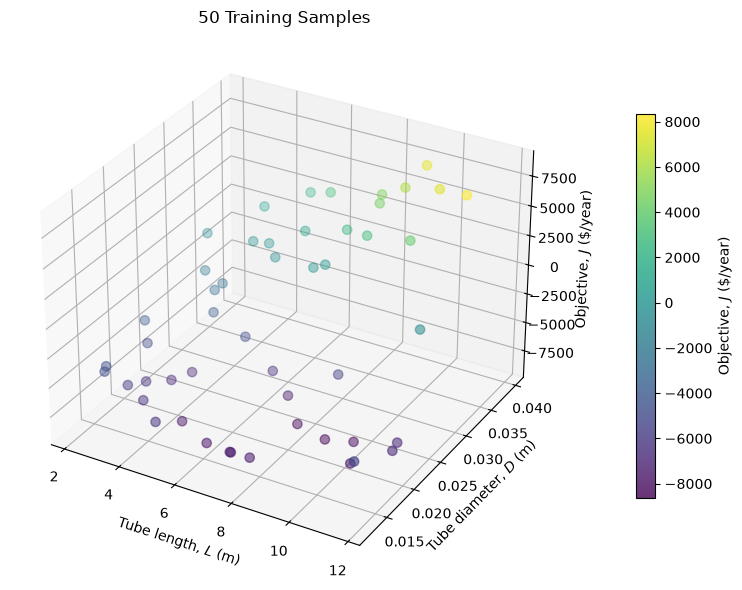

In [5]:
N_SAMPLES = 50

L_samples = np.random.uniform(L_MIN, L_MAX, N_SAMPLES)
D_samples = np.random.uniform(D_MIN, D_MAX, N_SAMPLES)

J_samples = np.empty(N_SAMPLES)

for i in range(N_SAMPLES):
    J_samples[i] = heat_exchanger_objective(L_samples[i], D_samples[i])

data = pd.DataFrame({
    "L_m": L_samples,
    "D_m": D_samples,
    "Objective_$": J_samples
})

data.head()

# 3D scatter plot of the 100 training samples
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(L_samples, D_samples, J_samples,
    c=J_samples, cmap="viridis", s=45, alpha=0.8)

ax.set_xlabel("Tube length, $L$ (m)")
ax.set_ylabel("Tube diameter, $D$ (m)")
ax.set_zlabel(r'Objective, $J$ (\$/year)')
ax.set_title(f"{N_SAMPLES} Training Samples")

fig.colorbar(scatter, ax=ax, shrink=0.7,
    pad=0.1, label=r'Objective, $J$ (\$/year)')

plt.tight_layout()
plt.show()


## 6. Scale the training data

The input variables have very different numerical scales, since $L$ is measured in meters while $D$ is only a few hundredths of a meter.

We therefore standardize both the inputs and the objective before training the MLP.


In [6]:
X = np.column_stack((L_samples, D_samples))
y = J_samples.reshape(-1, 1)

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_scaled = x_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(y).ravel()


## 7. Train the MLP surrogate

The surrogate has two inputs,

$$
(L,D),
$$

two hidden layers with 32 neurons each, and one scalar output,

$$
\hat J(L,D).
$$

`MLPRegressor` is trained directly on all 100 samples. Since the full dataset contains only $N$ points and `batch_size=N`, each training iteration uses the entire dataset as one batch.


In [7]:
mlp = MLPRegressor(
    hidden_layer_sizes=(32, 32),
    activation="tanh",
    solver="adam",
    alpha=1e-5,
    learning_rate_init=0.01,
    batch_size=N_SAMPLES,
    max_iter=5000,
    random_state=0)

mlp.fit(X_scaled, y_scaled)

print(f"Training iterations: {mlp.n_iter_}")
print(f"Final training loss: {mlp.loss_:.6e}")

Training iterations: 111
Final training loss: 2.661285e-03


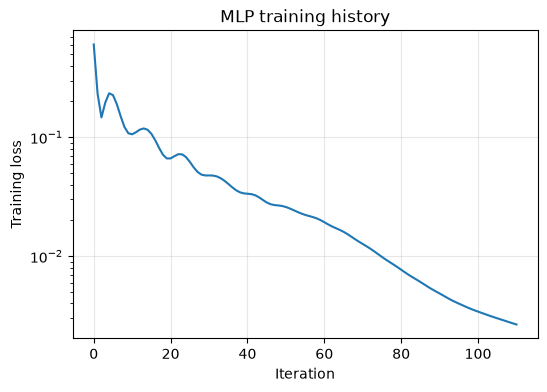

In [8]:
plt.figure(figsize=(6, 4))
plt.semilogy(mlp.loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Training loss")
plt.title("MLP training history")
plt.grid(alpha=0.3)
plt.show()


## 8. Convenience function for the trained surrogate

The function below accepts physical values of $(L,D)$ and returns the MLP prediction in the original objective units.


In [9]:
def mlp_objective(L, D):
    X_query = np.array([[L, D]])
    X_query_scaled = x_scaler.transform(X_query)

    y_query_scaled = mlp.predict(X_query_scaled).reshape(-1, 1)
    y_query = y_scaler.inverse_transform(y_query_scaled)

    return float(y_query[0, 0])


## 9. Optimize the trained MLP using SciPy BFGS

Ordinary BFGS is an unconstrained optimizer. To keep the search inside the physical design domain without changing algorithms, introduce unconstrained variables $z_L$ and $z_D$ and map them into the design space using the logistic function,

$$
s(z)=\frac{1}{1+e^{-z}}.
$$

Then

$$
L
=
L_{\min}
+
(L_{\max}-L_{\min})s(z_L)
$$

and

$$
D
=
D_{\min}
+
(D_{\max}-D_{\min})s(z_D).
$$

BFGS therefore remains unconstrained while every proposed design stays inside the allowed physical range.


In [10]:
import scipy.optimize as opt

result = opt.minimize(
    fun=lambda x: mlp_objective(x[0], x[1]),
    x0=[6.0, 0.025], method="L-BFGS-B",
    bounds=[(L_MIN, L_MAX), (D_MIN, D_MAX)])

L_bfgs, D_bfgs = result.x
J_bfgs_mlp = result.fun

print(f"Optimal L = {L_bfgs:.4f} m")
print(f"Optimal D = {D_bfgs:.5f} m")
print(f"Predicted J = {J_bfgs_mlp:.2f} $/year")

Optimal L = 7.5967 m
Optimal D = 0.02000 m
Predicted J = -9008.60 $/year



## 10. Generate the gridded true and surrogate surfaces

The dense grid below is used **only for visualization and ground-truth comparison**.

In a genuinely expensive engineering problem, evaluating such a dense grid could be prohibitively expensive. The surrogate itself was still trained using only the original $N$ simulator evaluations.


In [11]:
N_L = 50
N_D = 50

L_grid = np.linspace(L_MIN, L_MAX, N_L)
D_grid = np.linspace(D_MIN, D_MAX, N_D)

LL, DD = np.meshgrid(L_grid, D_grid, indexing="ij")

J_true_grid = np.empty_like(LL)
J_mlp_grid = np.empty_like(LL)

for i in range(N_L):
    for j in range(N_D):
        J_true_grid[i, j] = heat_exchanger_objective(LL[i, j], DD[i, j])
        J_mlp_grid[i, j] = mlp_objective(LL[i, j], DD[i, j])

# True optimum approximated from the dense simulator grid
true_idx = np.unravel_index(np.argmin(J_true_grid), J_true_grid.shape)

L_true = LL[true_idx]
D_true = DD[true_idx]
J_true = J_true_grid[true_idx]

print("True gridded optimum")
print(f"L = {L_true:.5f} m")
print(f"D = {D_true:.6f} m")
print(f"J = {J_true:.3f} $/year")

True gridded optimum
L = 7.71429 m
D = 0.018857 m
J = -9201.742 $/year



## 11. Compare the true and surrogate objective surfaces

The **black point** marks the minimum of the dense true-simulator grid.

The **red point** marks the design found by applying SciPy BFGS to the trained MLP surrogate.

On the true surface, the BFGS design is plotted using its **true simulator objective value**. On the MLP surface, the same design is plotted using the **MLP-predicted objective value**.


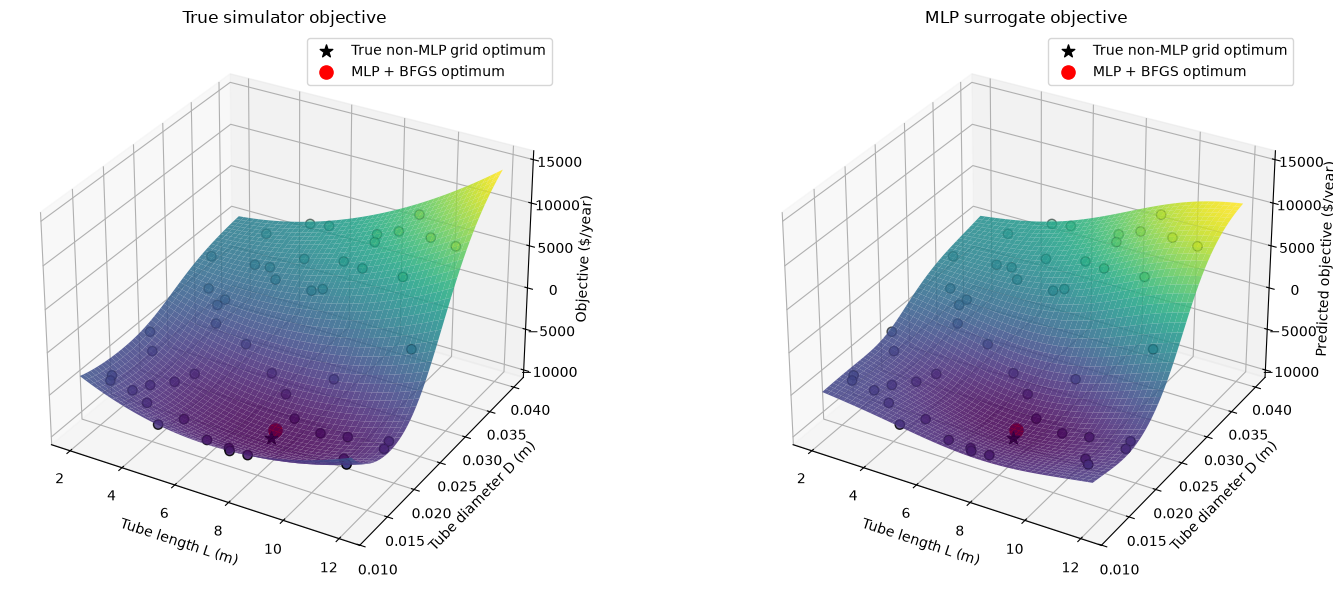

In [12]:
fig = plt.figure(figsize=(16, 6))

# ---------- True simulator surface ----------
ax1 = fig.add_subplot(1, 2, 1, projection="3d")

ax1.plot_surface(LL, DD, J_true_grid,
    cmap="viridis", alpha=0.85, linewidth=0)

ax1.scatter(L_true, D_true, J_true, marker='*',
    s=90, c="black", label="True non-MLP grid optimum")

ax1.scatter(L_bfgs, D_bfgs, J_bfgs_mlp,
    s=90, c="red", label="MLP + BFGS optimum")

ax1.scatter(L_samples, D_samples, J_samples,
    c=J_samples, cmap="viridis", s=45, edgecolors='k')

ax1.set_xlabel("Tube length L (m)")
ax1.set_ylabel("Tube diameter D (m)")
ax1.set_zlabel("Objective ($/year)")
ax1.set_title("True simulator objective")
ax1.legend()

# ---------- MLP surrogate surface ----------
ax2 = fig.add_subplot(1, 2, 2, projection="3d")

ax2.plot_surface(LL, DD, J_mlp_grid,
    cmap="viridis", alpha=0.85, linewidth=0)

ax2.scatter(L_true, D_true, J_true, marker='*',
    s=90, c="black", label="True non-MLP grid optimum")

ax2.scatter(L_bfgs, D_bfgs, J_bfgs_mlp,
    s=90, c="red", label="MLP + BFGS optimum")

ax2.scatter(L_samples, D_samples, J_samples,
    c=J_samples, cmap="viridis", s=45, edgecolors='k')

# This is important. Both plots must have the same x-y-z limits.
ax2.set_xlim(ax1.get_xlim())
ax2.set_ylim(ax1.get_ylim())
ax2.set_zlim(ax1.get_zlim())

ax2.set_xlabel("Tube length L (m)")
ax2.set_ylabel("Tube diameter D (m)")
ax2.set_zlabel("Predicted objective ($/year)")
ax2.set_title("MLP surrogate objective")
ax2.legend()

plt.tight_layout()
plt.show()


## 12. Numerical comparison

A good surrogate optimizer should propose a design close to the true optimum even though it was trained using only 100 simulator evaluations.


In [13]:
comparison = pd.DataFrame({
    "Solution": ["True gridded optimum", "MLP + BFGS optimum"],
    "L_m": [L_true, L_bfgs],
    "D_m": [D_true, D_bfgs],
    "Objective_$/yr": [J_true, J_bfgs_mlp]})

comparison

,Solution,L_m,D_m,Objective_$/yr
0,True gridded optimum,7.714286,0.018857,-9201.741715
1,MLP + BFGS optimum,7.596711,0.020001,-9008.595332


## Main Lesson

The original optimization problem is

$$\min_{L,D} J(L,D),$$

but evaluating $J$ is expensive and solvers require repeatedly solving the heat-exchanger model.

Instead, we sampled the simulator only 100 times and trained

$$(L,D) \longrightarrow \hat J_{\mathrm{MLP}}(L,D).$$

We then solved

$$
\min_{L,D}\hat J_{\mathrm{MLP}}(L,D)
$$

using BFGS.

This is the basic idea of **surrogate-based optimization**:

$$
\boxed{
\text{expensive simulator}
\rightarrow
\text{sparse samples}
\rightarrow
\text{machine-learning surrogate}
\rightarrow
\text{optimize surrogate}
}
$$